In [1]:
from eregion.tasks import ImageCreator, ImageResult
from eregion.tasks.custom import guess_image_type_from_filename_DEIMOS, load_image_fits_DEIMOS
from eregion.tasks.calibration import MasterBias, CalibrationResult
from eregion.tasks.preprocessing import BiasSubtraction, ScanSubtraction, SigmaClipMasking

import numpy as np
import matplotlib.pyplot as plt
import os
import glob2
from copy import deepcopy
import importlib

# Example: DEIMOS science focal plane characterization

In [2]:
basepath = '/Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI'
runid = '20260718*'
rawpath = glob2.glob(os.path.join(basepath, runid))[0]
outpath = rawpath.replace('/DTU_dettest/','/DTU_detreduce/')
if not os.path.exists(outpath):
    os.makedirs(outpath)

### Calproc

In [3]:
# Load bias images
creator = ImageCreator(detector_config = '../eregion/configs/detectors/deimos_sci.yaml')
res = creator.run(input_source = os.path.join(rawpath,'*bias*.fits'),
                  identifier_func = guess_image_type_from_filename_DEIMOS,
                  fileloader_func = load_image_fits_DEIMOS,
                  data_on_demand = True)

# make master bias
master_bias_task = MasterBias(method='median')
mb_res = master_bias_task.run(bias_images=res.data('type == "bias"'))


2026-07-24 11:07:36,436 - DetectorConfig - INFO - Config loaded from file '../eregion/configs/detectors/deimos_sci.yaml'
2026-07-24 11:07:36,437 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI/20260718-001407/*bias*.fits is a glob pattern
2026-07-24 11:07:48,513 - MasterBias - INFO - Setting method 'median' for task MasterBias.


In [4]:
# cleanup memory
del res
# save master bias result obj
mb_res.save(outpath)

In [5]:
# load master bias result obj
mb_res = CalibrationResult.load(outpath)
mb_res.master_bias

,type,exptime,det_id,filename,object
0,master_bias,0.0,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x10c434550>
1,master_bias,0.0,det_2,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x11802b610>
2,master_bias,0.0,det_3,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x10caae670>
3,master_bias,0.0,det_4,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x11802af30>
4,master_bias,0.0,det_5,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x11802a7b0>
5,master_bias,0.0,det_6,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x11802be30>
6,master_bias,0.0,det_7,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x10b64b070>
7,master_bias,0.0,det_8,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x114366490>


### Preproc

Sanity checks for each step

In [6]:
def quick_plot(img):
    vmin, vmax = np.percentile(img.data.values, [5, 95])
    img.show(cmap='gray', vmin=vmin, vmax=vmax, origin='lower')

2026-07-24 11:08:04,686 - datamodels.image - WARNING - Mask key 'sigma_clip_mask' not found in DetImage masks. Showing unmasked data.


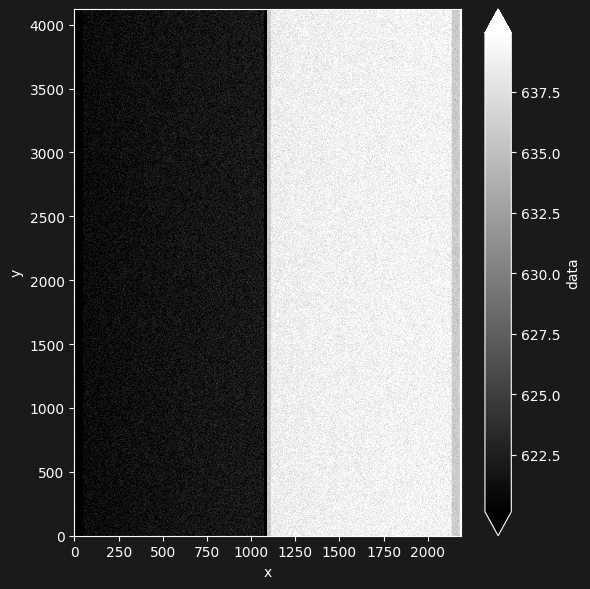

In [7]:
# plot master bias
quick_plot(mb_res.master_bias[0])

In [8]:
## Loadig first pair at exptime 0
creator = ImageCreator(detector_config='../eregion/configs/detectors/deimos_sci.yaml', max_batch_size=2)

flpair = creator.run(input_source='/Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI/20260718*/*SCI_1_flat_0.032*.fits',
                  identifier_func=guess_image_type_from_filename_DEIMOS,
                  fileloader_func=load_image_fits_DEIMOS,
                  data_on_demand=True)
flpair.data

2026-07-24 11:17:09,956 - DetectorConfig - INFO - Config loaded from file '../eregion/configs/detectors/deimos_sci.yaml'
2026-07-24 11:17:09,956 - DetectorConfig - INFO - Config loaded from file '../eregion/configs/detectors/deimos_sci.yaml'
2026-07-24 11:17:09,957 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI/20260718*/*SCI_1_flat_0.032*.fits is a glob pattern
2026-07-24 11:17:09,957 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI/20260718*/*SCI_1_flat_0.032*.fits is a glob pattern


,type,exptime,det_id,filename,object
0,flat,0.032,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x113ac32f0>
1,flat,0.032,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x117eef930>


2026-07-24 11:17:17,169 - datamodels.image - WARNING - Mask key 'sigma_clip_mask' not found in DetImage masks. Showing unmasked data.


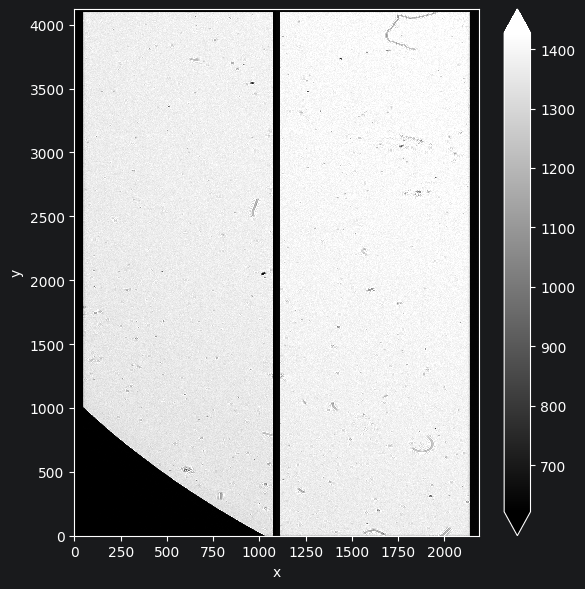

In [9]:
quick_plot(flpair.data[0])

2026-07-24 11:17:24,667 - datamodels.image - WARNING - Mask key 'sigma_clip_mask' not found in DetImage masks. Showing unmasked data.


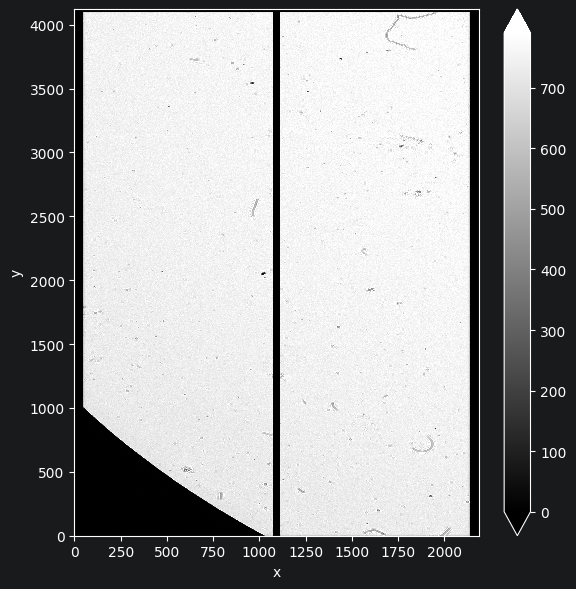

In [10]:
# Do bias sub
bias_sub = BiasSubtraction(quick=True)

after_bs = bias_sub.run(images=deepcopy(flpair.data), master_bias=mb_res.master_bias)
quick_plot(after_bs.data[0])

2026-07-24 11:17:33,628 - ScanSubtraction - INFO - Setting method 'median_by_axis' for task ScanSubtraction.
2026-07-24 11:17:35,073 - datamodels.image - WARNING - Mask key 'sigma_clip_mask' not found in DetImage masks. Showing unmasked data.


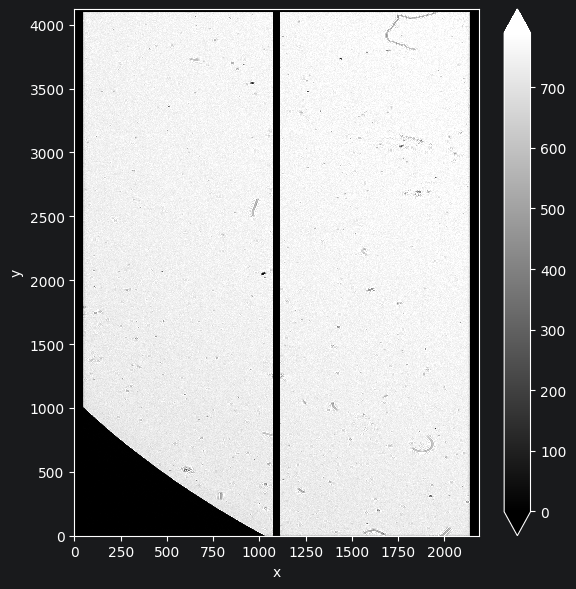

In [11]:
# Do overscan sub
oscan_sub = ScanSubtraction(which_scan='serial_overscan', method='median_by_axis')

after_osub = oscan_sub.run(images=deepcopy(after_bs.data))
quick_plot(after_osub.data[0])

2026-07-24 11:17:39,285 - sigma_clip_masking - INFO - Setting method 'ccd' for task sigma_clip_masking.


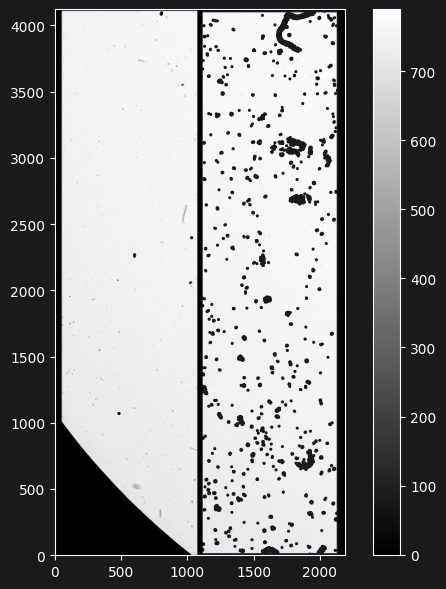

In [12]:
# Do sigma clip
cr_mask = SigmaClipMasking(sigma_clip_args={'sigma_lower':5, 'sigma_upper':5}) # set n_jobs=1 to be able to debug in pycharm inside parallelized jobs

after_cr = cr_mask.run(images=deepcopy(after_osub.data))
quick_plot(after_cr.data[0])

In [13]:
# Do PTC
import eregion.tasks.ptc as ptc
importlib.reload(ptc)

ptc_task = ptc.PTC()
pres = ptc_task.run(images=deepcopy(after_cr.data))

2026-07-24 11:18:01,062 - PTC - INFO - Doing per output stats on #0 image of 2
2026-07-24 11:18:01,957 - PTC - INFO - Calculating correlation coefficients
2026-07-24 11:18:04,590 - PTC - INFO - Calculating correlation coefficients
2026-07-24 11:18:06,179 - PTC - INFO - Doing per output stats on #1 image of 2
2026-07-24 11:18:07,089 - PTC - INFO - Calculating correlation coefficients
2026-07-24 11:18:09,643 - PTC - INFO - Calculating correlation coefficients
2026-07-24 11:18:11,253 - PTC - INFO - Doing diff pair analysis on index 0 and 1
2026-07-24 11:18:16,727 - PTC - INFO - Calculating correlation coefficients
2026-07-24 11:18:22,703 - PTC - INFO - Calculating correlation coefficients
2026-07-24 11:18:24,258 - PTC - INFO - Processed 2 flats, upto exptime 0.032


In [14]:
pres.ptc_table

,n_masked,med,mean,std,mad,skew,kurt,skewtest,skewtestp,kurttest,...,oscan_skewtest,oscan_skewtestp,oscan_kurttest,oscan_kurttestp,PSD,dPSD,det_id,output,exptime,diff
0,1848,738.621574,661.050144,231.083954,28.067979,-2.460585,4.197890,-1245.264823,0.000000,631.972845,...,189.748651,0.000000,114.890690,0.0,"[[9357845.283001326, 149.92266048119475, 97.44...","[[19445.125209299385, 0.9512116845162345, 0.52...",det_1,E,0.032,False
1,364988,756.141266,755.522348,24.699788,24.568455,-0.102718,0.123388,-81.933045,0.000000,46.500595,...,183.936891,0.000000,110.134402,0.0,"[[9969966.26923877, 160.13580720534378, 103.10...","[[14685.168622735771, 1.0246600523476088, 0.54...",det_1,F,0.032,False
2,3124,738.621941,661.085434,231.037317,28.061266,-2.461287,4.201420,-1245.260605,0.000000,632.098311,...,189.239657,0.000000,114.555773,0.0,"[[9353143.756280692, 150.1300539315452, 97.911...","[[19447.31706664232, 0.9577972265131448, 0.521...",det_1,E,0.032,False
3,368080,756.122700,755.529328,24.719519,24.570508,-0.098285,0.131600,-78.382299,0.000000,49.388090,...,184.165143,0.000000,110.293851,0.0,"[[9949454.624108983, 160.4558033790253, 103.43...","[[14701.306281336247, 1.0272109865183494, 0.55...",det_1,F,0.032,False
4,32262,-0.016376,-0.003953,22.220257,20.276530,0.001243,0.356379,1.036634,0.299906,126.593101,...,-0.206104,0.836710,52.619609,0.0,"[[88.54448212674974, 80.49375682241664, 81.720...","[[0.5652107492103501, 0.34358709924747893, 0.3...",det_1,E,0.032,True
5,13025,-0.007584,-0.010100,24.024983,24.015505,0.002104,0.007179,1.758518,0.078659,2.990373,...,-2.247919,0.024581,60.457735,0.0,"[[82.82022216195308, 80.90786445426889, 81.449...","[[0.5327778756436191, 0.34811230746785937, 0.3...",det_1,F,0.032,True


In [15]:
# save to fits
pres.save(outpath)

In [16]:
# load from fits
pres = ptc.PTCResult.load(outpath)
pres.ptc_table

,n_masked,med,mean,std,mad,skew,kurt,skewtest,skewtestp,kurttest,...,oscan_skewtest,oscan_skewtestp,oscan_kurttest,oscan_kurttestp,PSD,dPSD,det_id,output,exptime,diff
0,1848,738.621574,661.050144,231.083954,28.067979,-2.460585,4.197890,-1245.264823,0.000000,631.972845,...,189.748651,0.000000,114.890690,0.0,"[[9357845.283001326, 149.92266048119475, 97.44...","[[19445.125209299385, 0.9512116845162345, 0.52...",det_1,E,0.032,False
1,364988,756.141266,755.522348,24.699788,24.568455,-0.102718,0.123388,-81.933045,0.000000,46.500595,...,183.936891,0.000000,110.134402,0.0,"[[9969966.26923877, 160.13580720534378, 103.10...","[[14685.168622735771, 1.0246600523476088, 0.54...",det_1,F,0.032,False
2,3124,738.621941,661.085434,231.037317,28.061266,-2.461287,4.201420,-1245.260605,0.000000,632.098311,...,189.239657,0.000000,114.555773,0.0,"[[9353143.756280692, 150.1300539315452, 97.911...","[[19447.31706664232, 0.9577972265131448, 0.521...",det_1,E,0.032,False
3,368080,756.122700,755.529328,24.719519,24.570508,-0.098285,0.131600,-78.382299,0.000000,49.388090,...,184.165143,0.000000,110.293851,0.0,"[[9949454.624108983, 160.4558033790253, 103.43...","[[14701.306281336247, 1.0272109865183494, 0.55...",det_1,F,0.032,False
4,32262,-0.016376,-0.003953,22.220257,20.276530,0.001243,0.356379,1.036634,0.299906,126.593101,...,-0.206104,0.836710,52.619609,0.0,"[[88.54448212674974, 80.49375682241664, 81.720...","[[0.5652107492103501, 0.34358709924747893, 0.3...",det_1,E,0.032,True
5,13025,-0.007584,-0.010100,24.024983,24.015505,0.002104,0.007179,1.758518,0.078659,2.990373,...,-2.247919,0.024581,60.457735,0.0,"[[82.82022216195308, 80.90786445426889, 81.449...","[[0.5327778756436191, 0.34811230746785937, 0.3...",det_1,F,0.032,True


### Everything together

In [17]:
creator = ImageCreator(detector_config='../eregion/configs/detectors/deimos_sci.yaml', max_batch_size=2)
bias_sub = BiasSubtraction()
oscan_sub = ScanSubtraction(which_scan='serial_overscan', method='median_by_axis')
cr_mask = SigmaClipMasking(sigma_clip_args={'sigma_lower':5, 'sigma_upper':5})
ptc_task = ptc.PTC()

count = 0
# Load flat images in batches (lazy mode)
for flpair in creator.lazy_run(input_source='/Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI/20260718*/*flat*.fits',
                  identifier_func=guess_image_type_from_filename_DEIMOS,
                  fileloader_func=load_image_fits_DEIMOS,
                  data_on_demand=True):
    flpair = bias_sub.run(images=flpair.data, master_bias=mb_res.master_bias)
    flpair = oscan_sub.run(images=flpair.data)
    flpair = cr_mask.run(images=flpair.data)
    ptcres = ptc_task.run(images=flpair.data)

    if count==0:
        preproc_res = flpair
        ptc_res = ptcres
    else:
        preproc_res = preproc_res.combine(flpair)
        ptc_res = ptc_res.combine(ptcres)
    count+=1
    print('Pairs processed: ', count)
    if count>=1:
        break


2026-07-24 11:18:49,467 - DetectorConfig - INFO - Config loaded from file '../eregion/configs/detectors/deimos_sci.yaml'
2026-07-24 11:18:49,467 - DetectorConfig - INFO - Config loaded from file '../eregion/configs/detectors/deimos_sci.yaml'
2026-07-24 11:18:49,467 - DetectorConfig - INFO - Config loaded from file '../eregion/configs/detectors/deimos_sci.yaml'
2026-07-24 11:18:49,468 - ScanSubtraction - INFO - Setting method 'median_by_axis' for task ScanSubtraction.
2026-07-24 11:18:49,468 - ScanSubtraction - INFO - Setting method 'median_by_axis' for task ScanSubtraction.
2026-07-24 11:18:49,469 - sigma_clip_masking - INFO - Setting method 'ccd' for task sigma_clip_masking.
2026-07-24 11:18:49,469 - sigma_clip_masking - INFO - Setting method 'ccd' for task sigma_clip_masking.
2026-07-24 11:18:49,469 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI/20260718*/*flat*.fits is a glob pattern
2026-07-24 11:18:49,469 

Pairs processed:  1


In [18]:
ptc_res.save(outpath)